# ✈️ ETL de Tráfico Aéreo con OpenSky Network  
## Ingesta, Limpieza, Enriquecimiento y Construcción del Data Lake (Bronze → Silver → Gold)

La disponibilidad creciente de datos aeronáuticos en tiempo real permite analizar patrones de movilidad aérea, el comportamiento dinámico de las aeronaves y métricas operativas a escala global.  
Este notebook implementa un **pipeline ETL completo**, basado en la arquitectura **Bronze → Silver → Gold**, utilizando información proveniente del endpoint público de **OpenSky Network**.

El objetivo principal es construir un flujo de ingeniería de datos que permita:

- **ingestar datos estáticos y dinámicos**,  
- **limpiarlos y normalizarlos**,  
- **enriquecerlos con metadatos técnicos**,  
- **persistirlos en un Data Lake**,  
- y obtener un **dataset final analítico** listo para exploración y análisis.

El diseño del pipeline está orientado **conceptualmente** al uso de **Delta Lake** como formato de persistencia en entornos productivos.  
En este notebook, debido a restricciones del entorno de ejecución, la persistencia se realiza en formatos columnar estándar **Parquet mediante Spark**, utilizando el filesystem DBFS de Databricks como entorno de staging, manteniendo la semántica y organización propias de la arquitectura Bronze → Silver → Gold.

Este notebook representa la **ejecución manual** del pipeline y funciona como base para validación, pruebas y documentación.  
En una etapa posterior, este mismo flujo podrá ser **orquestado con Prefect** y **migrado a un entorno cloud con Delta Lake**, pero aquí nos enfocamos en la validación lógica y funcional del ETL.

---

## 🛩️ Variables principales provistas por OpenSky

- identificador único **ICAO24**  
- país de origen  
- latitud y longitud  
- altitudes barométricas y geométricas  
- velocidad, rumbo y tasa vertical  
- estado en tierra o en vuelo  
- timestamp del servidor  
- metadatos estáticos (fabricante, modelo, typecode, año, motores)

Los datos dinámicos y estáticos se integran para construir un snapshot completo del estado de las aeronaves en la capa *Gold*.

---

# 🎯 Objetivos del pipeline

## **Bronze — Extracción**
- Consumir el endpoint `states/all` y el archivo de metadatos.  
- Convertir JSON a estructuras tabulares.  
- Incorporar timestamps y persistir el material crudo en la capa Bronze del Data Lake.

## **Silver — Transformación**
- Limpieza estructural y tipificación.  
- Estandarización de fechas, coordenadas y campos categóricos.  
- Creación de columnas temporales (`snapshot_time`, `snapshot_hour`).  
- Preparación de tablas limpias y consistentes.

## **Gold — Enriquecimiento, Métricas y Visualizaciones**
- Integración dinámica + estática mediante `icao24`.  
- Cálculo de métricas aeronáuticas clave.  
- Visualizaciones exploratorias del snapshot.  
- Exportación opcional a CSV/Parquet.

---

# 🧭 Alcance actual

Este notebook implementa la **totalidad del pipeline en un entorno de desarrollo**.  
Se utiliza para:

- validar cada etapa de transformación,  
- consolidar el snapshot final,  
- documentar el proceso completo,  
- y dejar preparado el proyecto para una futura orquestación o migración cloud con Delta Lake (sin ejecutarlas aquí).

---

## 📘 Estructura del notebook

0) Configuración inicial  
1) Autenticación y lectura de configuración  
2) Capa Bronze — Extracción y almacenamiento crudo  
3) Capa Silver — Limpieza, normalización y particionado  
4) Capa Gold — Métricas, enriquecimiento y dataset final  
5) Conclusiones del pipeline


## 0. Configuración inicial

En esta sección se cargan las dependencias del proyecto y las funciones auxiliares definidas en `etl_utils.py`, y se establece la configuración base necesaria para la ejecución del pipeline ETL en Azure Databricks.

En particular, aquí se realiza:

- la importación de librerías y utilidades compartidas,
- la configuración de acceso a Azure Data Lake Storage Gen2 (ADLS) para operar con rutas `abfss://`,
- la definición de rutas base por contenedor para las capas Bronze, Silver y Gold (`bronze_root`, `silver_root`, `gold_root`), y una ruta base neutral para outputs (`datalake_root`).

### Acceso a ADLS Gen2

El pipeline persiste los datos en ADLS Gen2 mediante rutas `abfss://`. Dado que las capas se organizan en contenedores separados (`bronze`, `silver`, `gold`), se definen roots específicos por capa para garantizar un esquema de rutas consistente en toda la ejecución.

Centralizar esta configuración al inicio del notebook permite mantener el flujo ordenado, evitar duplicaciones y garantizar que todas las etapas del ETL utilicen un esquema de rutas consistente y compatible con Spark.

In [0]:
# Funciones auxiliares
from src.etl_utils import *

# Utilidades de apoyo (solo inspección / debug)
from pprint import pprint

print("✅ Funciones auxiliares importadas correctamente.")

✅ Funciones auxiliares importadas correctamente.


In [0]:
# Configuración de acceso a ADLS Gen2 (Account Key desde Key Vault)
storage_account = "stopenskyeltdev"

spark.conf.set(
    f"fs.azure.account.key.{storage_account}.dfs.core.windows.net",
    dbutils.secrets.get(scope="kv-opensky-scope", key="storage-account-key")
)

datalake_root = f"abfss://landing@{storage_account}.dfs.core.windows.net/etl_datalake"
bronze_root   = f"abfss://bronze@{storage_account}.dfs.core.windows.net/etl_datalake"
silver_root   = f"abfss://silver@{storage_account}.dfs.core.windows.net/etl_datalake"
gold_root     = f"abfss://gold@{storage_account}.dfs.core.windows.net/etl_datalake"

print("🔐 Acceso a ADLS configurado correctamente.")
print("📁 Roots definidos:")
print("DataLake →", datalake_root)
print("Bronze   →", bronze_root)
print("Silver   →", silver_root)
print("Gold     →", gold_root)

🔐 Acceso a ADLS configurado correctamente.
📁 Roots definidos:
DataLake → abfss://landing@stopenskyeltdev.dfs.core.windows.net/etl_datalake
Bronze   → abfss://bronze@stopenskyeltdev.dfs.core.windows.net/etl_datalake
Silver   → abfss://silver@stopenskyeltdev.dfs.core.windows.net/etl_datalake
Gold     → abfss://gold@stopenskyeltdev.dfs.core.windows.net/etl_datalake


## 1. Autenticación y lectura de configuración

El pipeline utiliza `pipeline.conf` para centralizar los parámetros del proyecto, separando la configuración del código y evitando exponer credenciales o rutas sensibles dentro del notebook.

### Configuración de la API de OpenSky
```ini
[api-opensky]
base_url = https://opensky-network.org/api/states/all
username = ...
password = ...
```

- El endpoint público de OpenSky **no requiere autenticación obligatoria**, pero el archivo permite almacenar credenciales opcionales para *Basic Auth*, útiles si se desea mejorar los límites de uso.
- Mantener estos valores en un archivo externo facilita limpieza del notebook y habilita una futura integración con servicios como **Azure Key Vault**.

### Configuración de Prefect (opcional)
```ini
[prefect]
api_key =
```

- Prefect 2.x no requiere API Key para ejecución local.
- El bloque se conserva por consistencia con otros proyectos ETL y para permitir una futura conexión con **Prefect Cloud**.

### Lectura del archivo
La carga se realiza mediante `ConfigParser`, permitiendo acceder a los parámetros de forma segura y estructurada (URL base, credenciales opcionales, rutas del Data Lake, parámetros de Prefect).


In [0]:
# Se instancia el parser y se lee el archivo de configuración
from configparser import ConfigParser
import os

parser = ConfigParser()

# Databricks environment: explicit path to pipeline.conf
config_path = os.path.abspath(os.path.join(os.getcwd(), "..", "pipeline.conf"))
parser.read(config_path)

['/Workspace/Users/elias.m.fernandez@outlook.com/ETL_OpenSky_Aviation/pipeline.conf']

In [0]:
# Parámetros de conexión
api_config = parser["api-opensky"]
base_url = api_config["base_url"]

In [0]:
print("CWD:", os.getcwd())
print("Config sections:", parser.sections())

CWD: /Workspace/Users/elias.m.fernandez@outlook.com/ETL_OpenSky_Aviation/notebooks
Config sections: ['api-opensky', 'prefect']


In [0]:
print("📄 Configuración cargada correctamente.")
print(f"URL base: {base_url}")

📄 Configuración cargada correctamente.
URL base: https://opensky-network.org/api/states/all


In [0]:
# Prueba de conexión a la API OpenSky
response = requests.get(base_url)

if response.status_code == 200:
    data = response.json()
    print(f"La petición fue exitosa. Tipo de respuesta: {type(data)}")

    # Claves principales del JSON
    print(f"Claves principales recibidas: {list(data.keys())[:5]}")

    # Inspección parcial de 'states'
    print("\nPrimeras 2 aeronaves registradas:")
    pprint(data["states"][:2])

else:
    print(f"❌ Error en la petición: {response.status_code}, {response.content}")
print("✅ Prueba de conexión a la API realizada.")

La petición fue exitosa. Tipo de respuesta: <class 'dict'>
Claves principales recibidas: ['time', 'states']

Primeras 2 aeronaves registradas:
[['39de4f',
  'TVF50WP ',
  'France',
  1769723499,
  1769723499,
  2.0945,
  48.9052,
  3352.8,
  False,
  173.55,
  226.08,
  0,
  None,
  3208.02,
  '0762',
  False,
  0],
 ['a21b74',
  'TWY235  ',
  'United States',
  1769723499,
  1769723499,
  -80.6695,
  37.3926,
  13761.72,
  False,
  241.28,
  186.49,
  4.55,
  None,
  13555.98,
  None,
  False,
  0]]
✅ Prueba de conexión a la API realizada.


## 2. Capa Bronze — Extracción y almacenamiento crudo

En esta etapa se realiza la extracción directa de datos desde OpenSky Network, con el objetivo de conservarlos en su forma más fiel dentro de la capa 🟤 Bronze del Data Lake.

Los datos dinámicos provienen del endpoint `states/all` e incluyen, entre otros atributos:

- Identificador ICAO24 y callsign
- País de origen
- Posición geográfica (latitud, longitud)
- Altitudes barométrica y geométrica
- Velocidad, rumbo y tasa vertical
- Estado operativo (en tierra o en vuelo)
- Timestamp del servidor correspondiente a la captura

Cada aeronave es representada inicialmente como una lista ordenada de 17 elementos. En Bronze se prioriza preservar los datos crudos, sin aplicar aún procesos de limpieza, tipificación avanzada ni enriquecimiento.

En este entorno, la persistencia de Bronze se realiza en **ADLS Gen2** mediante rutas `abfss://`, utilizando el contenedor `bronze` como destino.

### 2.1 Extracción de datos estáticos

Se realiza una ingesta *full* del recurso estático `aircraftDatabase.csv`, publicado por OpenSky Network como tabla de referencia de aeronaves (fabricante, modelo, typecode, operador, entre otros).

Dado que este dataset cambia poco en el tiempo, se incorpora en su totalidad en cada ejecución y se sobrescribe la versión previa.

El archivo CSV se descarga directamente a **ADLS Gen2** dentro del contenedor `bronze` (zona `raw`) y luego se lee con Apache Spark para su posterior persistencia en Bronze en formato Parquet, preservando el contenido original sin aplicar aún procesos de limpieza ni transformación.

In [0]:
metadata_url = "https://opensky-network.org/datasets/metadata/aircraftDatabase.csv"
metadata_adls_path = f"{bronze_root}/raw/aircraftDatabase.csv"

dbutils.fs.mkdirs(f"{bronze_root}/raw")
dbutils.fs.cp(metadata_url, metadata_adls_path)

df_aircraft = (
    spark.read
         .option("header", True)
         .option("inferSchema", True)
         .csv(metadata_adls_path)
)

print("📄 Dataset de metadatos cargado correctamente.")
print(f"Filas: {df_aircraft.count()} | Columnas: {len(df_aircraft.columns)}")
df_aircraft.show(3)

📄 Dataset de metadatos cargado correctamente.
Filas: 520068 | Columnas: 27
+------+------------+----------------+--------------------+---------+--------+------------+----------+----------------+--------+----------------+------------+------------+--------------------+-------+----------+----------+------+----------+---------------+-----------------+--------------------+-----+-----+-----+-----+-------------------+
|icao24|registration|manufacturericao|    manufacturername|    model|typecode|serialnumber|linenumber|icaoaircrafttype|operator|operatorcallsign|operatoricao|operatoriata|               owner|testreg|registered|  reguntil|status|     built|firstflightdate|seatconfiguration|             engines|modes| adsb|acars|notes|categoryDescription|
+------+------------+----------------+--------------------+---------+--------+------------+----------+----------------+--------+----------------+------------+------------+--------------------+-------+----------+----------+------+----------+-----

### 2.2 Extracción de datos dinámicos

Para los datos dinámicos se utiliza la información provista por el endpoint `states/all` de OpenSky Network, que ofrece el estado en tiempo real de miles de aeronaves a nivel global.

Dado que estos datos se actualizan continuamente, cada ejecución del pipeline captura un **snapshot independiente** del tráfico aéreo correspondiente al instante de consulta.

En esta etapa, el JSON recibido se transforma a un **DataFrame de Spark** mediante un **schema explícito**, conservando la semántica de los campos del recurso y sin aplicar aún procesos de limpieza o enriquecimiento.  
Adicionalmente, se incorpora la columna `snapshot_time` a partir del timestamp provisto por el servidor (`json_data["time"]`).

No se aplica una lógica de actualización incremental, ya que:

- el conjunto de aeronaves presentes varía en cada consulta,
- los registros representan estados instantáneos y no eventos transaccionales entre ejecuciones.

Este enfoque permite preservar la evolución temporal del tráfico aéreo entre ejecuciones y habilita análisis históricos posteriores en las capas Silver y Gold.

In [0]:
# --- Extracción de datos dinámicos — OpenSky states/all ---

# Obtención del snapshot dinámico mediante la función auxiliar
json_data = get_opensky_states()

# Vista preliminar del JSON recibido
print("🔑 Claves principales:", list(json_data.keys()))
print("🛫 Cantidad de aeronaves detectadas:", len(json_data["states"]))

# Visualización de los primeros registros crudos
print("\nPrimeras 2 aeronaves (formato crudo):")
pprint(json_data["states"][:2])

🔑 Claves principales: ['time', 'states']
🛫 Cantidad de aeronaves detectadas: 10661

Primeras 2 aeronaves (formato crudo):
[['39de4f',
  'TVF50WP ',
  'France',
  1769723546,
  1769723546,
  2.0152,
  48.855,
  3276.6,
  False,
  168.81,
  225.99,
  -4.88,
  None,
  3124.2,
  '0762',
  False,
  0],
 ['a21b74',
  'TWY235  ',
  'United States',
  1769723546,
  1769723546,
  -80.6841,
  37.2907,
  13936.98,
  False,
  241.79,
  186.47,
  3.58,
  None,
  13731.24,
  None,
  False,
  0]]


In [0]:
# --- Conversión del snapshot dinámico a Spark DataFrame ---

states_schema = StructType([
    StructField("icao24", StringType(), True),
    StructField("callsign", StringType(), True),
    StructField("origin_country", StringType(), True),
    StructField("time_position", LongType(), True),
    StructField("last_contact", LongType(), True),
    StructField("longitude", DoubleType(), True),
    StructField("latitude", DoubleType(), True),
    StructField("baro_altitude", DoubleType(), True),
    StructField("on_ground", BooleanType(), True),
    StructField("velocity", DoubleType(), True),
    StructField("true_track", DoubleType(), True),
    StructField("vertical_rate", DoubleType(), True),
    StructField("sensors", ArrayType(IntegerType()), True),
    StructField("geo_altitude", DoubleType(), True),
    StructField("squawk", StringType(), True),
    StructField("spi", BooleanType(), True),
    StructField("position_source", IntegerType(), True),
])

df_states = spark.createDataFrame(json_data["states"], schema=states_schema)

df_states = df_states.withColumn(
    "snapshot_time",
    from_unixtime(lit(json_data["time"]))
)

print("📄 Snapshot dinámico convertido a Spark DataFrame.")
df_states.show(3)

📄 Snapshot dinámico convertido a Spark DataFrame.
+------+--------+--------------+-------------+------------+---------+--------+-------------+---------+--------+----------+-------------+-------+------------+------+-----+---------------+-------------------+
|icao24|callsign|origin_country|time_position|last_contact|longitude|latitude|baro_altitude|on_ground|velocity|true_track|vertical_rate|sensors|geo_altitude|squawk|  spi|position_source|      snapshot_time|
+------+--------+--------------+-------------+------------+---------+--------+-------------+---------+--------+----------+-------------+-------+------------+------+-----+---------------+-------------------+
|39de4f|TVF50WP |        France|   1769723546|  1769723546|   2.0152|  48.855|       3276.6|    false|  168.81|    225.99|        -4.88|   NULL|      3124.2|  0762|false|              0|2026-01-29 21:52:27|
|a21b74|TWY235  | United States|   1769723546|  1769723546| -80.6841| 37.2907|     13936.98|    false|  241.79|    186.47|

### 2.3 Guardado en Bronze — Capa Bronze del Data Lake

Una vez realizada la extracción de los datos estáticos y dinámicos, ambos recursos se almacenan en la capa 🟤 Bronze del Data Lake.  
En esta etapa no se aplican transformaciones ni procesos de limpieza: los datos se preservan tal como fueron obtenidos desde la fuente, cumpliendo el propósito de Bronze como zona de almacenamiento crudo.

En este entorno, la persistencia se realiza sobre **ADLS Gen2** mediante rutas `abfss://`, utilizando el contenedor `bronze` como destino de almacenamiento.  
El diseño del pipeline mantiene la semántica Bronze → Silver → Gold y permite escalar a escenarios productivos sin modificar la lógica del ETL.

Los metadatos estáticos se guardan mediante una ingesta *full* (`mode="overwrite"`), ya que su contenido cambia poco y resulta más simple reemplazar el dataset completo en cada ejecución.

Los datos dinámicos provenientes de `states/all` se guardan como *snapshots* sucesivos (`mode="append"`), conservando el histórico de capturas. La trazabilidad temporal se mantiene a través de la columna `snapshot_time`.

In [0]:
# --- Definición de rutas del Data Lake (Bronze - ADLS) ---

bronze_dir  = f"{bronze_root}/api_opensky"
static_dir  = f"{bronze_dir}/aircraft_metadata"
dynamic_dir = f"{bronze_dir}/states"

print("📁 Rutas Bronze definidas:")
print("Static  →", static_dir)
print("Dynamic →", dynamic_dir)

📁 Rutas Bronze definidas:
Static  → abfss://bronze@stopenskyeltdev.dfs.core.windows.net/etl_datalake/api_opensky/aircraft_metadata
Dynamic → abfss://bronze@stopenskyeltdev.dfs.core.windows.net/etl_datalake/api_opensky/states


In [0]:
# --- Guardado en Bronze — Metadatos estáticos (Parquet) ---
# Ingesta full: se sobrescribe en cada ejecución.

df_aircraft.write.mode("overwrite").parquet(static_dir)

print("🟤 Metadatos estáticos guardados correctamente en Bronze (Parquet).")


🟤 Metadatos estáticos guardados correctamente en Bronze (Parquet).


In [0]:
# --- Guardado en Bronze — Snapshot dinámico (Parquet) ---
# Snapshot crudo: se conserva histórico mediante append.

df_states.write.mode("append").parquet(dynamic_dir)

print("🟤 Snapshot dinámico guardado correctamente en Bronze (Parquet).")

🟤 Snapshot dinámico guardado correctamente en Bronze (Parquet).


## 3. Capa Silver — Limpieza, normalización y particionado

La capa Silver aplica transformaciones sobre los datos almacenados en Bronze con el objetivo de obtener un conjunto de datos limpio, tabular y estructurado, adecuado para análisis posteriores.

En esta etapa se realizan:

- renombrado de columnas,
- estandarización de tipos,
- conversión y derivación de variables temporales,
- selección de atributos relevantes,
- manejo/validación de valores nulos,
- enriquecimiento opcional mediante cruce entre datasets.

El procesamiento se organiza en dos pasos:

### 3.1 Metadatos estáticos (aircraft_metadata)

Depuración de columnas, estandarización de nombres y construcción de la tabla de referencia de aeronaves, utilizada como base para enriquecer los datos dinámicos.

### 3.2 Datos dinámicos (states/all)

Normalización del snapshot, asignación de nombres descriptivos a las columnas, tipificación y preparación para análisis temporal.  
En el guardado de Silver se conserva histórico y se particiona por hora (`snapshot_hour`) para optimizar consultas posteriores.

Este enfoque garantiza un esquema consistente y una base sólida para la etapa Gold, donde se generarán datasets finales listos para consumo analítico.

### 3.1 Metadatos estáticos — Construcción de la tabla de referencia de aeronaves

El dataset de metadatos de aeronaves obtenido desde OpenSky contiene información descriptiva asociada a cada código `icao24`.

Aunque estos datos cambian poco en el tiempo, llegan con numerosas columnas incompletas y atributos que no aportan valor analítico. En esta etapa se construye una tabla de referencia limpia y estable mediante:

- eliminación de columnas con nulos al 100%,
- verificación y eliminación de duplicados en la clave primaria `icao24`,
- detección y eliminación de columnas sin variabilidad (0 o 1 valor distinto),
- selección de atributos descriptivos relevantes para enriquecer los datos dinámicos,
- tipificación suave, asegurando que los campos descriptivos se representen como `string`.

El resultado es una tabla compacta, consistente y adecuada para enriquecer los datos dinámicos procesados en la siguiente etapa.

In [0]:
# --- Lectura de metadatos estáticos desde Bronze (Parquet) ---
df_aircraft_bronze = spark.read.parquet(static_dir)

In [0]:
# Se crea una referencia para aplicar las transformaciones
df_aircraft_cleaned = df_aircraft_bronze

In [0]:
# Vista preliminar
df_aircraft_cleaned.show(3)

+------+------------+----------------+--------------------+---------+--------+------------+----------+----------------+--------+----------------+------------+------------+--------------------+-------+----------+----------+------+----------+---------------+-----------------+--------------------+-----+-----+-----+-----+-------------------+
|icao24|registration|manufacturericao|    manufacturername|    model|typecode|serialnumber|linenumber|icaoaircrafttype|operator|operatorcallsign|operatoricao|operatoriata|               owner|testreg|registered|  reguntil|status|     built|firstflightdate|seatconfiguration|             engines|modes| adsb|acars|notes|categoryDescription|
+------+------------+----------------+--------------------+---------+--------+------------+----------+----------------+--------+----------------+------------+------------+--------------------+-------+----------+----------+------+----------+---------------+-----------------+--------------------+-----+-----+-----+-----+-

In [0]:
# --- Inspección inicial del dataset estático 
df_aircraft_cleaned.printSchema()

root
 |-- icao24: string (nullable = true)
 |-- registration: string (nullable = true)
 |-- manufacturericao: string (nullable = true)
 |-- manufacturername: string (nullable = true)
 |-- model: string (nullable = true)
 |-- typecode: string (nullable = true)
 |-- serialnumber: string (nullable = true)
 |-- linenumber: string (nullable = true)
 |-- icaoaircrafttype: string (nullable = true)
 |-- operator: string (nullable = true)
 |-- operatorcallsign: string (nullable = true)
 |-- operatoricao: string (nullable = true)
 |-- operatoriata: string (nullable = true)
 |-- owner: string (nullable = true)
 |-- testreg: string (nullable = true)
 |-- registered: date (nullable = true)
 |-- reguntil: date (nullable = true)
 |-- status: string (nullable = true)
 |-- built: date (nullable = true)
 |-- firstflightdate: date (nullable = true)
 |-- seatconfiguration: string (nullable = true)
 |-- engines: string (nullable = true)
 |-- modes: boolean (nullable = true)
 |-- adsb: boolean (nullable = t

In [0]:
# --- Verificación de valores nulos en la clave primaria (icao24)
nulos = df_aircraft_cleaned.filter(col("icao24").isNull()).count()
print(f"Cantidad de valores nulos en 'icao24': {nulos}")

Cantidad de valores nulos en 'icao24': 1


In [0]:
# --- Verificación de valores vacíos o espacios en 'icao24' ---
vacios = df_aircraft_cleaned.filter(
    (col("icao24").isNotNull()) & (trim(col("icao24")) == "")
).count()

print(f"Cantidad de valores vacíos en 'icao24': {vacios}")

Cantidad de valores vacíos en 'icao24': 0


In [0]:
# --- Verificación de duplicados en 'icao24' ---
duplicados = (
    df_aircraft_cleaned
        .groupBy("icao24")
        .count()
        .filter(col("count") > 1)
        .count()
)

print(f"Cantidad de valores duplicados en 'icao24': {duplicados}")

Cantidad de valores duplicados en 'icao24': 11


In [0]:
# --- Inspección de los valores duplicados en 'icao24' ---
df_aircraft_cleaned \
    .groupBy("icao24") \
    .count() \
    .filter(col("count") > 1) \
    .join(df_aircraft_cleaned, on="icao24", how="inner") \
    .orderBy("icao24") \
    .show()

+-------------+-----+------------+----------------+----------------+-------------------+--------+------------+----------+----------------+--------------------+----------------+------------+------------+--------------------+-------+----------+--------+------+-----+---------------+-----------------+-------+-----+-----+-----+--------------------+--------------------+
|       icao24|count|registration|manufacturericao|manufacturername|              model|typecode|serialnumber|linenumber|icaoaircrafttype|            operator|operatorcallsign|operatoricao|operatoriata|               owner|testreg|registered|reguntil|status|built|firstflightdate|seatconfiguration|engines|modes| adsb|acars|               notes| categoryDescription|
+-------------+-----+------------+----------------+----------------+-------------------+--------+------------+----------+----------------+--------------------+----------------+------------+------------+--------------------+-------+----------+--------+------+-----+--

In [0]:
# --- Eliminación de valores nulos en la clave primaria (icao24) ---
df_aircraft_cleaned = df_aircraft_cleaned.filter(col("icao24").isNotNull())

In [0]:
# --- Eliminación de duplicados en la clave primaria (icao24) ---
df_aircraft_cleaned = df_aircraft_cleaned.dropDuplicates(["icao24"])

In [0]:
# --- Verificación post-limpieza ---
nulos = df_aircraft_cleaned.filter(col("icao24").isNull()).count()
duplicados = (
    df_aircraft_cleaned
        .groupBy("icao24")
        .count()
        .filter(col("count") > 1)
        .count()
)

print("Nulos en icao24:", nulos)
print("Duplicados en icao24:", duplicados)

Nulos en icao24: 0
Duplicados en icao24: 0


In [0]:
# --- Estandarización de nombres de columnas (Silver) ---
# Se normalizan todos los nombres de columnas para garantizar un esquema consistente.
# Este formato (snake_case + minúsculas) es el estándar utilizado en pipelines ETL
# y evita ambigüedades en transformaciones posteriores y uniones entre datasets.

import re

new_cols = [
    re.sub(r"[^a-z0-9_]", "", re.sub(r"\s+", "_", c.strip().lower()))
    for c in df_aircraft_cleaned.columns
]

df_aircraft_cleaned = df_aircraft_cleaned.toDF(*new_cols)

In [0]:
# --- Eliminación de columnas con 100% de valores nulos ---
# En esta etapa se descartan las columnas cuyo contenido es completamente nulo.
# Estas variables no aportan información a la tabla de referencia de aeronaves y
# solo generarían ruido en las siguientes etapas (joins, estadísticas, almacenamiento).

total_rows = df_aircraft_cleaned.count()

cols_to_drop = [
    c for c in df_aircraft_cleaned.columns
    if df_aircraft_cleaned.select(count(col(c))).collect()[0][0] == 0
]

df_aircraft_cleaned = df_aircraft_cleaned.drop(*cols_to_drop)

print(f"📉 Columnas eliminadas por nulos al 100%: {cols_to_drop}")
print(f"📦 Total de columnas restantes: {len(df_aircraft_cleaned.columns)}")

📉 Columnas eliminadas por nulos al 100%: ['status', 'seatconfiguration']
📦 Total de columnas restantes: 25


In [0]:
# --- Definición de columnas candidatas según documentación de OpenSky ---

# Atributos principales esperados en la tabla de referencia de aeronaves
cols_principales = [
    "icao24",
    "registration",
    "manufacturername",
    "model",
    "typecode",
    "operator"
]

# Atributos complementarios (útiles si contienen variabilidad)
cols_complementarias = [
    "owner",
    "built",
    "engines",
    "modes",
    "adsb",
    "acars"
]

# Combinación de columnas candidatas
cols_candidatas = cols_principales + cols_complementarias

# Se filtran solo las columnas presentes en el dataset
cols_candidatas = [c for c in cols_candidatas if c in df_aircraft_cleaned.columns]

print("📌 Columnas candidatas detectadas:", cols_candidatas)

📌 Columnas candidatas detectadas: ['icao24', 'registration', 'manufacturername', 'model', 'typecode', 'operator', 'owner', 'built', 'engines', 'modes', 'adsb', 'acars']


In [0]:
# --- Verificación de variabilidad para cada columna candidata ---

print("🔎 Verificación de variabilidad en columnas candidatas:\n")

cols_constantes = []

for col_name in cols_candidatas:
    n_unicos = (
        df_aircraft_cleaned
            .select(col(col_name))
            .distinct()
            .filter(col(col_name).isNotNull())
            .count()
    )

    print(f"{col_name}: {n_unicos} valores únicos")

    # Si la columna tiene 0 o 1 valores distintos → no aporta información
    if n_unicos <= 1:
        cols_constantes.append(col_name)

print("\n⚠️ Columnas con variabilidad nula:", cols_constantes)

🔎 Verificación de variabilidad en columnas candidatas:

icao24: 520054 valores únicos
registration: 514302 valores únicos
manufacturername: 41568 valores únicos
model: 34483 valores únicos
typecode: 1933 valores únicos
operator: 4018 valores únicos
owner: 224892 valores únicos
built: 381 valores únicos
engines: 7522 valores únicos
modes: 1 valores únicos
adsb: 1 valores únicos
acars: 1 valores únicos

⚠️ Columnas con variabilidad nula: ['modes', 'adsb', 'acars']


In [0]:
# --- Eliminación de columnas sin información útil ---

df_aircraft_cleaned = df_aircraft_cleaned.drop(*cols_constantes)

print("🧹 Columnas eliminadas:", cols_constantes)
print("📦 Columnas restantes:", df_aircraft_cleaned.columns)

🧹 Columnas eliminadas: ['modes', 'adsb', 'acars']
📦 Columnas restantes: ['icao24', 'registration', 'manufacturericao', 'manufacturername', 'model', 'typecode', 'serialnumber', 'linenumber', 'icaoaircrafttype', 'operator', 'operatorcallsign', 'operatoricao', 'operatoriata', 'owner', 'testreg', 'registered', 'reguntil', 'built', 'firstflightdate', 'engines', 'notes', 'categorydescription']


In [0]:
# --- Selección final de atributos relevantes para la tabla de referencia de aeronaves ---

cols_finales = [
    "icao24",
    "registration",
    "manufacturername",
    "model",
    "typecode",
    "owner",
    "built",
    "engines"
]

# Verificación final: se mantienen solo las columnas presentes tras la depuración
cols_finales = [c for c in cols_finales if c in df_aircraft_cleaned.columns]

# Construcción de la tabla de referencia (versión Silver)
df_aircraft_cleaned = df_aircraft_cleaned.select(*cols_finales)

print("📘 Tabla de referencia de aeronaves — Silver:")
df_aircraft_cleaned.show(5)


📘 Tabla de referencia de aeronaves — Silver:
+------+------------+--------------------+----------------+--------+--------------------+----------+--------------------+
|icao24|registration|    manufacturername|           model|typecode|               owner|     built|             engines|
+------+------------+--------------------+----------------+--------+--------------------+----------+--------------------+
|a2ee69|      N2882Z|               Piper|           PA-18|    PA18|      Kroner David S|1959-01-01|CONT MOTOR C90 SE...|
|a4a791|      N3997M|               Piper|           PA-12|    PA12|Glover William Scott|1947-01-01|LYCOMING 0-235 SE...|
|a3e838|      N35075|               Piper|          J3L-65|      J3|      Bendure Ryan R|1940-01-01|LYCOMING 0-145B S...|
|a0f1fa|      N160DA|              Hughes|            369A|    H500|Military Museum O...|1969-01-01|   ALLISON T63-A-700|
|400c30|      G-FIFA|Cessna Aircraft C...|CESSNA 404 Titan|    C404|    Rvl Aviation Ltd|1980-01-01|2

In [0]:
# Conversión de fechas a string (solo si la columna existe)
if "built" in df_aircraft_cleaned.columns:
    df_aircraft_cleaned = df_aircraft_cleaned.withColumn(
        "built",
        date_format(col("built"), "yyyy-MM-dd")
    )

In [0]:
# --- Verificación inicial de tipos de datos ---
# Se revisa el tipo actual de cada columna antes de la tipificación suave.
df_aircraft_cleaned.dtypes

[('icao24', 'string'),
 ('registration', 'string'),
 ('manufacturername', 'string'),
 ('model', 'string'),
 ('typecode', 'string'),
 ('owner', 'string'),
 ('built', 'string'),
 ('engines', 'string')]

In [0]:
# --- Tipificación suave: se asegura tipo string en columnas descriptivas ---
# Convertimos columnas a string para evitar valores mixtos 
# (mezclas de números, nulos y cadenas que suelen aparecer en datos provenientes de APIs).
# Se transforman explícitamente a tipo "string" para garantizar consistencia en Silver.
# Esta explicación detallada se incluye solo en 3.1; en 3.2 la conversión se aplicará de forma más breve.

cols_string = [
    "icao24",
    "registration",
    "manufacturername",
    "model",
    "typecode",
    "owner",
    "built",
    "engines"
]

# Conversión a string en Spark
for c in cols_string:
    if c in df_aircraft_cleaned.columns:
        df_aircraft_cleaned = df_aircraft_cleaned.withColumn(c, col(c).cast("string"))

print("✅ Tipificación suave aplicada (todas las columnas relevantes como string).")
df_aircraft_cleaned.dtypes

✅ Tipificación suave aplicada (todas las columnas relevantes como string).


[('icao24', 'string'),
 ('registration', 'string'),
 ('manufacturername', 'string'),
 ('model', 'string'),
 ('typecode', 'string'),
 ('owner', 'string'),
 ('built', 'string'),
 ('engines', 'string')]

### 3.2 Datos dinámicos — Normalización del snapshot de estados (states/all)

El endpoint `states/all` de OpenSky proporciona un **snapshot en tiempo real** del estado de las aeronaves detectadas en el momento de la consulta.  
Estos datos son **altamente volátiles** y cambian de un segundo a otro.

Contienen información fundamental para el análisis del tráfico aéreo, incluyendo:

- posición (`longitude`, `latitude`)
- altitud (`baro_altitude`, `geo_altitude`)
- velocidad (`velocity`)
- rumbo (`true_track`)
- tasa vertical (`vertical_rate`)
- estado operativo (`on_ground`) e indicadores adicionales
- timestamps (`time_position`, `last_contact`) y timestamp del snapshot (`snapshot_time`)

En Silver se aplican transformaciones para obtener un dataset **limpio, tipado y consistente**, listo para análisis temporal y persistencia:

- selección y renombrado de columnas relevantes,
- estandarización de tipos numéricos/booleanos/categóricos,
- conversión y derivación de variables temporales (incluyendo `snapshot_hour`),
- depuración de columnas con baja utilidad analítica cuando corresponde.

El resultado se almacena en la capa Silver en formato Parquet, conservando histórico y particionando por `snapshot_hour`.

### 3.2.1 Lectura de snapshots dinámicos desde Bronze

Los datos dinámicos se almacenan en Bronze como Parquet en el directorio `states`.  
Para iniciar el procesamiento en Silver, se lee el contenido completo del directorio desde `dynamic_dir` mediante Spark, manteniendo el procesamiento distribuido.

A partir de este DataFrame se aplican las transformaciones de limpieza y normalización definidas para la capa Silver.

In [0]:
# --- Lectura del snapshot más reciente desde Bronze (Parquet) ---
df_states_bronze = spark.read.parquet(dynamic_dir)

In [0]:
# Se crea una referencia para aplicar las transformaciones
df_states_cleaned = df_states_bronze

In [0]:
# Vista preliminar
df_states_cleaned.show(3)

+------+--------+--------------+-------------+------------+---------+--------+-------------+---------+--------+----------+-------------+-------+------------+------+-----+---------------+-------------------+
|icao24|callsign|origin_country|time_position|last_contact|longitude|latitude|baro_altitude|on_ground|velocity|true_track|vertical_rate|sensors|geo_altitude|squawk|  spi|position_source|      snapshot_time|
+------+--------+--------------+-------------+------------+---------+--------+-------------+---------+--------+----------+-------------+-------+------------+------+-----+---------------+-------------------+
|4cae69|RYR41BJ |       Ireland|   1769721706|  1769721706|  10.3249| 49.7705|      10972.8|    false|  229.08|    291.61|          0.0|   NULL|    10683.24|  3540|false|              0|2026-01-29 21:21:46|
|a3242e|N301MT  | United States|   1769721706|  1769721706| -82.1695|  38.596|     11209.02|    false|   200.7|     215.4|         -5.2|   NULL|     10896.6|  NULL|false|  

### 3.2.2 Normalización del snapshot dinámico

En Silver se normaliza el snapshot dinámico para obtener un dataset tabular, tipado y consistente para análisis temporal.

Las transformaciones aplicadas incluyen:

- estandarización de nombres de columnas según el orden oficial de OpenSky (ajustado a columnas presentes),
- evaluación de variabilidad en columnas candidatas y eliminación de aquellas sin información útil,
- conversión de timestamps (`time_position`, `last_contact`) a tipo `timestamp`,
- tipificación suave de columnas categóricas (`icao24`, `callsign`, `origin_country`, `squawk`) a `string`,
- creación de columnas temporales para control de ingesta y particionado en Silver (`snapshot_time`, `snapshot_hour`).

El resultado es un dataset dinámico limpio y consistente, listo para persistencia en Silver con particionado temporal y posterior enriquecimiento.

In [0]:
# --- Renombrado de columnas del snapshot dinámico (states/all) ---
# Estandariza el esquema según el orden oficial de OpenSky.
# Preserva la columna de control temporal si está presente.

column_names_full = [
    "icao24", "callsign", "origin_country",
    "time_position", "last_contact",
    "longitude", "latitude", "baro_altitude",
    "on_ground", "velocity", "true_track",
    "vertical_rate", "sensors", "geo_altitude",
    "squawk", "spi", "position_source"
]

cols_actuales = df_states_cleaned.columns

# Construcción del esquema final respetando snapshot_time si existe
if "snapshot_time" in cols_actuales:
    new_cols = column_names_full + ["snapshot_time"]
else:
    new_cols = column_names_full[:len(cols_actuales)]

# Validación estricta del esquema antes del renombrado
assert len(new_cols) == len(cols_actuales), (
    f"Schema mismatch: {len(cols_actuales)} columns present, "
    f"{len(new_cols)} column names provided."
)

df_states_cleaned = df_states_cleaned.toDF(*new_cols)

print("✅ Columnas renombradas correctamente:")
print(df_states_cleaned.columns)
df_states_cleaned.show(3)

✅ Columnas renombradas correctamente:
['icao24', 'callsign', 'origin_country', 'time_position', 'last_contact', 'longitude', 'latitude', 'baro_altitude', 'on_ground', 'velocity', 'true_track', 'vertical_rate', 'sensors', 'geo_altitude', 'squawk', 'spi', 'position_source', 'snapshot_time']
+------+--------+--------------+-------------+------------+---------+--------+-------------+---------+--------+----------+-------------+-------+------------+------+-----+---------------+-------------------+
|icao24|callsign|origin_country|time_position|last_contact|longitude|latitude|baro_altitude|on_ground|velocity|true_track|vertical_rate|sensors|geo_altitude|squawk|  spi|position_source|      snapshot_time|
+------+--------+--------------+-------------+------------+---------+--------+-------------+---------+--------+----------+-------------+-------+------------+------+-----+---------------+-------------------+
|4cae69|RYR41BJ |       Ireland|   1769721706|  1769721706|  10.3249| 49.7705|      10972

In [0]:
# --- Evaluación de variabilidad en columnas candidatas ---
# Se identifican columnas con valores constantes o sin presencia en el snapshot.

cols_candidatas_states = ["position_source", "sensors"]
cols_constantes_states = []

print("🔎 Verificación de variabilidad (states/all):\n")

for col_name in cols_candidatas_states:
    if col_name not in df_states_cleaned.columns:
        print(f"{col_name}: columna no presente en este snapshot")
        continue

    n_unicos = (
        df_states_cleaned
            .select(col(col_name))
            .distinct()
            .filter(col(col_name).isNotNull())
            .count()
    )

    print(f"{col_name}: {n_unicos} valores únicos")

    if n_unicos <= 1:
        cols_constantes_states.append(col_name)

print("\n⚠️ Columnas con variabilidad nula:", cols_constantes_states)

🔎 Verificación de variabilidad (states/all):

position_source: 1 valores únicos
sensors: 0 valores únicos

⚠️ Columnas con variabilidad nula: ['position_source', 'sensors']


In [0]:
# --- Eliminación de columnas sin información útil ---

df_states_cleaned = df_states_cleaned.drop(*cols_constantes_states)

print("🧹 Columnas eliminadas (states/all):", cols_constantes_states)
print("📦 Columnas restantes:", df_states_cleaned.columns)

🧹 Columnas eliminadas (states/all): ['position_source', 'sensors']
📦 Columnas restantes: ['icao24', 'callsign', 'origin_country', 'time_position', 'last_contact', 'longitude', 'latitude', 'baro_altitude', 'on_ground', 'velocity', 'true_track', 'vertical_rate', 'geo_altitude', 'squawk', 'spi', 'snapshot_time']


In [0]:
# --- Verificación inicial de tipos de datos ---
print("📊 Tipos de datos antes de la normalización (Bronze → Silver):")
df_states_cleaned.dtypes

📊 Tipos de datos antes de la normalización (Bronze → Silver):


[('icao24', 'string'),
 ('callsign', 'string'),
 ('origin_country', 'string'),
 ('time_position', 'bigint'),
 ('last_contact', 'bigint'),
 ('longitude', 'double'),
 ('latitude', 'double'),
 ('baro_altitude', 'double'),
 ('on_ground', 'boolean'),
 ('velocity', 'double'),
 ('true_track', 'double'),
 ('vertical_rate', 'double'),
 ('geo_altitude', 'double'),
 ('squawk', 'string'),
 ('spi', 'boolean'),
 ('snapshot_time', 'string')]

In [0]:
# --- Conversión de columnas temporales a datetime ---

df_states_cleaned = df_states_cleaned.withColumn(
    "time_position",
    from_unixtime(col("time_position")).cast("timestamp")
)

df_states_cleaned = df_states_cleaned.withColumn(
    "last_contact",
    from_unixtime(col("last_contact")).cast("timestamp")
)

In [0]:
df_states_cleaned.select("spi").distinct().show()

+-----+
|  spi|
+-----+
| true|
|false|
+-----+



In [0]:
df_states_cleaned.select("on_ground").distinct().show()

+---------+
|on_ground|
+---------+
|     true|
|    false|
+---------+



In [0]:
# --- Tipificación suave: conversión de columnas categóricas a string ---
cols_string_states = [
    "icao24",
    "callsign",
    "origin_country",
    "squawk"
]

# Conversión segura a string (evita problemas con valores mixtos)
for c in cols_string_states:
    if c in df_states_cleaned.columns:
        df_states_cleaned = df_states_cleaned.withColumn(c, col(c).cast("string"))

In [0]:
# --- Verificación final de tipos ---
print("📊 Tipos finales luego de la normalización Silver:")
df_states_cleaned.dtypes

📊 Tipos finales luego de la normalización Silver:


[('icao24', 'string'),
 ('callsign', 'string'),
 ('origin_country', 'string'),
 ('time_position', 'timestamp'),
 ('last_contact', 'timestamp'),
 ('longitude', 'double'),
 ('latitude', 'double'),
 ('baro_altitude', 'double'),
 ('on_ground', 'boolean'),
 ('velocity', 'double'),
 ('true_track', 'double'),
 ('vertical_rate', 'double'),
 ('geo_altitude', 'double'),
 ('squawk', 'string'),
 ('spi', 'boolean'),
 ('snapshot_time', 'string')]

In [0]:
# --- Creación de columnas de timestamp para control de ingesta y particionado ---

df_states_cleaned = df_states_cleaned.withColumn(
    "snapshot_time",
    current_timestamp()
)

df_states_cleaned = df_states_cleaned.withColumn(
    "snapshot_hour",
    date_format(col("snapshot_time"), "yyyy-MM-dd-HH")
)

### 3.3 Guardado en Silver — Persistencia en Data Lake

Una vez finalizada la normalización tanto de los metadatos estáticos como del snapshot dinámico, ambos datasets se almacenan en la capa 🥈 Silver del Data Lake en formato Parquet.

En Silver se preservan los datos depurados y tipificados, con:

- nombres de columnas descriptivos,
- tipos corregidos (timestamp, numéricos, booleanos y texto),
- columnas sin información útil eliminadas,
- columnas temporales derivadas (`snapshot_time`, `snapshot_hour`) para control de ingesta y particionado.

Los datos se almacenan en ADLS Gen2 (contenedor `silver`) bajo:

- `api_opensky/aircraft_metadata/` → metadatos estáticos normalizados  
- `api_opensky/states/` → snapshot dinámico limpio y particionado

Para el guardado se utiliza:

- `mode="overwrite"` para metadatos estáticos (tabla de referencia vigente),
- `mode="append"` para el snapshot dinámico, particionado por `snapshot_hour` para conservar el histórico de forma eficiente.

In [0]:
# --- Definición de rutas del Data Lake (Silver - ADLS) ---

silver_dir = f"{silver_root}/api_opensky"
silver_static_dir  = f"{silver_dir}/aircraft_metadata"
silver_dynamic_dir = f"{silver_dir}/states"

print("📁 Rutas Silver definidas:")
print("Static  →", silver_static_dir)
print("Dynamic →", silver_dynamic_dir)

📁 Rutas Silver definidas:
Static  → abfss://silver@stopenskyeltdev.dfs.core.windows.net/etl_datalake/api_opensky/aircraft_metadata
Dynamic → abfss://silver@stopenskyeltdev.dfs.core.windows.net/etl_datalake/api_opensky/states


In [0]:
# --- Guardado en Silver — Metadatos estáticos (Parquet) ---
# Tabla de referencia ya limpiada/normalizada para consumo analítico.
# En Silver se conserva únicamente la versión vigente, por eso se usa overwrite.

df_aircraft_cleaned.write.mode("overwrite").parquet(silver_static_dir)

print("🥈 Metadatos estáticos guardados correctamente en Silver (Parquet).")

🥈 Metadatos estáticos guardados correctamente en Silver (Parquet).


In [0]:
# --- Guardado en Silver — Snapshot dinámico (Parquet) ---
# Snapshot limpio/normalizado para análisis intermedio.
# Se conserva histórico con append y se particiona por hora para mejorar performance.

df_states_cleaned.write.mode("append").partitionBy("snapshot_hour").parquet(silver_dynamic_dir)

print("🥈 Snapshot dinámico guardado correctamente en Silver (Parquet).")

🥈 Snapshot dinámico guardado correctamente en Silver (Parquet).


## 4. Capa Gold — Métricas, enriquecimiento y dataset final  

La capa Gold constituye la fase final del pipeline y tiene como objetivo producir información lista para análisis, integrando los datos ya procesados en Silver y generando un dataset confiable para exploración, visualización o uso en herramientas de BI.

Mientras que:

- Bronze preserva los datos crudos,  
- Silver garantiza limpieza, tipificación y estructura,  
- Gold entrega datos analíticos enriquecidos y derivados.  

En esta etapa se desarrollan:

- métricas descriptivas del snapshot dinámico,  
- indicadores operativos (velocidad, altitudes, cobertura geográfica, etc.),  
- un dataset final enriquecido con metadatos estáticos de aeronaves,  
- visualizaciones básicas para validación,  
- exportaciones a CSV para consumo externo.  

El objetivo no es realizar un análisis exhaustivo del tráfico aéreo, sino demostrar el cierre profesional del flujo Bronze → Silver → Gold, entregando datos curados, documentados y analíticamente consistentes.

La capa Gold se organiza en las siguientes subsecciones:

### 4.1 Métricas del snapshot dinámico  
Cálculo de estadísticas esenciales que permiten validar la coherencia del snapshot y comprender su comportamiento general.

### 4.2 Enriquecimiento con la tabla de referencia de aeronaves  
Unión del snapshot dinámico con los metadatos estáticos (fabricante, modelo, typecode, año, motores) para construir el dataset final analítico.

### 4.3 Guardado en Gold — Data Lake (Parquet)  
Persistencia del dataset enriquecido en la capa Gold del Data Lake, manteniendo una estructura limpia y lista para consumo analítico.

### 4.4 Exportación a CSV  
Generación de versiones externas del dataset final para facilitar su uso fuera del entorno Databricks.

### 4.5 Visualizaciones del snapshot dinámico  
Gráficos de distribución de velocidades, altitudes, posiciones geográficas y países de origen para validar el contenido del dataset final.

### 4.6 Cierre del apartado Gold  
Resumen final del trabajo realizado y preparación del proyecto para su orquestación y futura migración a entornos productivos en la nube.




In [0]:
# --- Lectura completa desde Silver para la capa Gold ---
# Se leen todas las particiones disponibles del snapshot dinámico ya normalizado.
# En Gold trabajamos con el histórico acumulado para calcular métricas globales.
df_states_silver_all = spark.read.parquet(silver_dynamic_dir)

In [0]:
# Se crea una referencia para aplicar transformaciones en Gold
df_states_gold = df_states_silver_all

print("Registros leídos:", df_states_gold.count())

Registros leídos: 31125


In [0]:
# Vista preliminar
df_states_gold.show(3)

+------+--------+--------------+-------------------+-------------------+---------+--------+-------------+---------+--------+----------+-------------+------------+------+-----+--------------------+-------------+
|icao24|callsign|origin_country|      time_position|       last_contact|longitude|latitude|baro_altitude|on_ground|velocity|true_track|vertical_rate|geo_altitude|squawk|  spi|       snapshot_time|snapshot_hour|
+------+--------+--------------+-------------------+-------------------+---------+--------+-------------+---------+--------+----------+-------------+------------+------+-----+--------------------+-------------+
|4cae69|RYR41BJ |       Ireland|2026-01-29 21:21:46|2026-01-29 21:21:46|  10.3249| 49.7705|      10972.8|    false|  229.08|    291.61|          0.0|    10683.24|  3540|false|2026-01-29 21:55:...|2026-01-29-21|
|a3242e|N301MT  | United States|2026-01-29 21:21:46|2026-01-29 21:21:46| -82.1695|  38.596|     11209.02|    false|   200.7|     215.4|         -5.2|     10

### 4.1 Métricas del snapshot dinámico  

En esta sección se generan métricas descriptivas basadas en el snapshot dinámico procesado en la capa Silver.  
Estas métricas permiten validar la coherencia del dataset y obtener una visión general del tráfico aéreo capturado en la ingesta.

Antes de calcular los indicadores, los datos se leen nuevamente desde Silver y se normalizan los tipos clave,  
ya que ciertos formatos pueden requerir ajustes al ser persistidos y recargados desde archivos Parquet.  
Este paso asegura un dataset estable, tipado y consistente para el análisis.

**Indicadores principales a calcular**

- Cantidad total de aeronaves detectadas  
- Porcentaje de aeronaves en vuelo vs. en tierra  
- Distribución de velocidades  
  - promedio  
  - mínimo y máximo  
  - percentiles relevantes  
- Distribución de altitudes (baro_altitude, geo_altitude)  
- Top países de origen (origin_country)  

**Validación de calidad del snapshot**

- cantidad de callsign válidos  
- registros sin latitud / longitud  
- proporción de valores nulos en velocidad o altitud  

Estas métricas cumplen un doble propósito:

- Evaluar el estado y la calidad del snapshot dinámico.  
- Preparar el terreno para el enriquecimiento con los metadatos de aeronaves en la sección 4.2.

In [0]:
# --- Tipificación suave en Gold: se asegura tipo string en columnas descriptivas ---

cols_string_gold = [
    "icao24",
    "callsign",
    "origin_country",
    "squawk"
]

for c in cols_string_gold:
    df_states_gold = df_states_gold.withColumn(c, col(c).cast("string"))

print("✳️ Columnas categóricas casteadas a string:")
df_states_gold.select(cols_string_gold).printSchema()

✳️ Columnas categóricas casteadas a string:
root
 |-- icao24: string (nullable = true)
 |-- callsign: string (nullable = true)
 |-- origin_country: string (nullable = true)
 |-- squawk: string (nullable = true)



In [0]:
# --- Métricas principales del snapshot dinámico (Gold) ---

print("📌 Métricas iniciales del snapshot dinámico\n")

# 1) Cantidad total de aeronaves
total_aircraft = df_states_gold.count()
print(f"✈️ Total de aeronaves detectadas: {total_aircraft}")

# 2) Porcentaje de aeronaves en vuelo vs en tierra
en_tierra = df_states_gold.filter(col("on_ground") == True).count()
en_vuelo = total_aircraft - en_tierra

pct_vuelo = (en_vuelo / total_aircraft) * 100
pct_tierra = (en_tierra / total_aircraft) * 100

print(f"🛫 En vuelo: {en_vuelo} ({pct_vuelo:.2f}%)")
print(f"🛬 En tierra: {en_tierra} ({pct_tierra:.2f}%)")

# 3) Registros sin posición geográfica
sin_posicion = df_states_gold.filter(
    col("latitude").isNull() | col("longitude").isNull()
).count()
print(f"📍 Registros sin lat/long: {sin_posicion}")

# 4) Callsign válidos (no nulos, no vacíos)
callsign_validos = df_states_gold.filter(
    col("callsign").isNotNull() & (col("callsign") != "")
).count()
print(f"🔠 Callsign válidos: {callsign_validos}")

# 5) Top 10 países de origen
top_paises = (
    df_states_gold
    .groupBy("origin_country")
    .count()
    .orderBy(col("count").desc())
    .limit(10)
)

print("\n🌍 Top 10 países de origen:")
top_paises.show(truncate=False)

📌 Métricas iniciales del snapshot dinámico

✈️ Total de aeronaves detectadas: 31125
🛫 En vuelo: 28421 (91.31%)
🛬 En tierra: 2704 (8.69%)
📍 Registros sin lat/long: 264
🔠 Callsign válidos: 30567

🌍 Top 10 países de origen:
+--------------+-----+
|origin_country|count|
+--------------+-----+
|United States |19414|
|Canada        |1330 |
|United Kingdom|767  |
|Australia     |606  |
|Ireland       |595  |
|Turkey        |587  |
|Germany       |568  |
|Spain         |399  |
|China         |391  |
|France        |382  |
+--------------+-----+



In [0]:
# --- Métricas generales del snapshot dinámico (Gold) ---

print("=== MÉTRICAS GENERALES DEL SNAPSHOT ===\n")

# Tipificación de columna booleana para cálculos correctos
df_states_gold = df_states_gold.withColumn("on_ground", col("on_ground").cast("boolean"))

total_registros = df_states_gold.count()
en_tierra = df_states_gold.filter(col("on_ground") == True).count()
en_vuelo = total_registros - en_tierra

print(f"✈️ Total de aeronaves detectadas: {total_registros}")
print(f"🟦 En vuelo: {en_vuelo} ({en_vuelo/total_registros:.2%})")
print(f"🟩 En tierra: {en_tierra} ({en_tierra/total_registros:.2%})")

print("\n--- Registros completos vs. incompletos ---")
registros_completos = df_states_gold.filter(
    col("longitude").isNotNull() & col("latitude").isNotNull()
).count()

print(f"📍 Registros con posición válida: {registros_completos}")
print(f"⚠️ Registros sin lat/lon: {total_registros - registros_completos}")


=== MÉTRICAS GENERALES DEL SNAPSHOT ===

✈️ Total de aeronaves detectadas: 31125
🟦 En vuelo: 28421 (91.31%)
🟩 En tierra: 2704 (8.69%)

--- Registros completos vs. incompletos ---
📍 Registros con posición válida: 30861
⚠️ Registros sin lat/lon: 264


In [0]:
# --- Métricas de velocidad ---
# Se evalúan velocidad promedio, mínimos, máximos y percentiles.
# También se identifica la proporción de valores faltantes.

print("=== MÉTRICAS DE VELOCIDAD ===\n")

# Estadísticos básicos
stats_vel = df_states_gold.select("velocity").describe().toPandas()

promedio = float(stats_vel[stats_vel["summary"] == "mean"]["velocity"])
minima   = float(stats_vel[stats_vel["summary"] == "min"]["velocity"])
maxima   = float(stats_vel[stats_vel["summary"] == "max"]["velocity"])

print(f"Promedio: {promedio:.2f} m/s")
print(f"Mínima:  {minima:.2f} m/s")
print(f"Máxima:  {maxima:.2f} m/s")

# Percentiles (aproximados en Spark)
p25, p50, p75 = df_states_gold.approxQuantile("velocity", [0.25, 0.50, 0.75], 0.01)

print(f"P25:     {p25:.2f} m/s")
print(f"P50:     {p50:.2f} m/s")
print(f"P75:     {p75:.2f} m/s")

# Valores faltantes
total_registros = df_states_gold.count()
faltantes_vel = df_states_gold.filter(col("velocity").isNull()).count()

print(f"\n⚠️ Valores faltantes en 'velocity': {faltantes_vel} ({faltantes_vel/total_registros:.2%})")

=== MÉTRICAS DE VELOCIDAD ===



/home/spark-e0bfacba-5933-47ba-84f7-39/.ipykernel/2085/command-5312085117116474-3153756844:10: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  promedio = float(stats_vel[stats_vel["summary"] == "mean"]["velocity"])
/home/spark-e0bfacba-5933-47ba-84f7-39/.ipykernel/2085/command-5312085117116474-3153756844:11: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  minima   = float(stats_vel[stats_vel["summary"] == "min"]["velocity"])
/home/spark-e0bfacba-5933-47ba-84f7-39/.ipykernel/2085/command-5312085117116474-3153756844:12: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  maxima   = float(stats_vel[stats_vel["summary"] == "max"]["velocity"])


Promedio: 146.66 m/s
Mínima:  0.00 m/s
Máxima:  577.94 m/s
P25:     58.21 m/s
P50:     164.67 m/s
P75:     222.17 m/s

⚠️ Valores faltantes en 'velocity': 14 (0.04%)


In [0]:
# --- Métricas de altitud (barométrica y geométrica) ---
# Se convierten las columnas a numérico para evitar errores al calcular estadísticas.

print("=== MÉTRICAS DE ALTITUD ===\n")

# Cast explícito a double
df_states_gold = df_states_gold.withColumn("baro_altitude", col("baro_altitude").cast("double"))
df_states_gold = df_states_gold.withColumn("geo_altitude", col("geo_altitude").cast("double"))

# Estadísticos básicos (Baro)
stats_baro = df_states_gold.select("baro_altitude").describe().toPandas()
baro_mean = float(stats_baro[stats_baro["summary"] == "mean"]["baro_altitude"])
baro_min  = float(stats_baro[stats_baro["summary"] == "min"]["baro_altitude"])
baro_max  = float(stats_baro[stats_baro["summary"] == "max"]["baro_altitude"])

print("📌 Baro Altitude (m):")
print(f"  Promedio: {baro_mean:.2f}")
print(f"  Mínima:   {baro_min:.2f}")
print(f"  Máxima:   {baro_max:.2f}")

# Estadísticos básicos (Geo)
stats_geo = df_states_gold.select("geo_altitude").describe().toPandas()
geo_mean = float(stats_geo[stats_geo["summary"] == "mean"]["geo_altitude"])
geo_min  = float(stats_geo[stats_geo["summary"] == "min"]["geo_altitude"])
geo_max  = float(stats_geo[stats_geo["summary"] == "max"]["geo_altitude"])

print("\n📌 Geo Altitude (m):")
print(f"  Promedio: {geo_mean:.2f}")
print(f"  Mínima:   {geo_min:.2f}")
print(f"  Máxima:   {geo_max:.2f}")

# Valores faltantes
total_registros = df_states_gold.count()
faltantes_alt = df_states_gold.filter(col("baro_altitude").isNull()).count()

print(f"\n⚠️ Valores faltantes en altitudes baro: {faltantes_alt} ({faltantes_alt/total_registros:.2%})")

=== MÉTRICAS DE ALTITUD ===



/home/spark-e0bfacba-5933-47ba-84f7-39/.ipykernel/2085/command-5312085117116475-4087424260:12: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  baro_mean = float(stats_baro[stats_baro["summary"] == "mean"]["baro_altitude"])
/home/spark-e0bfacba-5933-47ba-84f7-39/.ipykernel/2085/command-5312085117116475-4087424260:13: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  baro_min  = float(stats_baro[stats_baro["summary"] == "min"]["baro_altitude"])
/home/spark-e0bfacba-5933-47ba-84f7-39/.ipykernel/2085/command-5312085117116475-4087424260:14: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  baro_max  = float(stats_baro[stats_baro["summary"] == "max"]["baro_altitude"])


📌 Baro Altitude (m):
  Promedio: 6275.48
  Mínima:   -304.80
  Máxima:   27035.76


/home/spark-e0bfacba-5933-47ba-84f7-39/.ipykernel/2085/command-5312085117116475-4087424260:23: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  geo_mean = float(stats_geo[stats_geo["summary"] == "mean"]["geo_altitude"])
/home/spark-e0bfacba-5933-47ba-84f7-39/.ipykernel/2085/command-5312085117116475-4087424260:24: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  geo_min  = float(stats_geo[stats_geo["summary"] == "min"]["geo_altitude"])
/home/spark-e0bfacba-5933-47ba-84f7-39/.ipykernel/2085/command-5312085117116475-4087424260:25: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  geo_max  = float(stats_geo[stats_geo["summary"] == "max"]["geo_altitude"])



📌 Geo Altitude (m):
  Promedio: 6292.00
  Mínima:   -960.12
  Máxima:   15026.64

⚠️ Valores faltantes en altitudes baro: 2872 (9.23%)


In [0]:
# --- Ranking de países de origen de aeronaves detectadas ---

print("=== TOP PAÍSES DE ORIGEN ===\n")

top_paises = (
    df_states_gold
    .groupBy("origin_country")
    .count()
    .orderBy(col("count").desc())
    .limit(10)
)

top_paises.show(truncate=False)

=== TOP PAÍSES DE ORIGEN ===

+--------------+-----+
|origin_country|count|
+--------------+-----+
|United States |19414|
|Canada        |1330 |
|United Kingdom|767  |
|Australia     |606  |
|Ireland       |595  |
|Turkey        |587  |
|Germany       |568  |
|Spain         |399  |
|China         |391  |
|France        |382  |
+--------------+-----+



In [0]:
# --- Validación de calidad del snapshot ---
# Se inspeccionan valores nulos y campos esenciales.

print("=== VERIFICACIÓN DE CALIDAD DEL SNAPSHOT ===\n")

# Registros sin callsign
sin_callsign = df_states_gold.filter(col("callsign").isNull()).count()
print("📡 Registros sin callsign:")
print(sin_callsign)

# Registros sin lat/lon
sin_posicion = df_states_gold.filter(
    col("latitude").isNull() | col("longitude").isNull()
).count()
print("\n📍 Registros sin lat/lon:")
print(sin_posicion)

# Proporción de nulos por columna
print("\n🔢 Proporción de nulos por columna:")

total_registros = df_states_gold.count()

nulls_by_col = {
    c: df_states_gold.filter(col(c).isNull()).count() / total_registros
    for c in df_states_gold.columns
}

for k, v in nulls_by_col.items():
    print(f"{k}: {v:.3f}")

=== VERIFICACIÓN DE CALIDAD DEL SNAPSHOT ===

📡 Registros sin callsign:
0

📍 Registros sin lat/lon:
264

🔢 Proporción de nulos por columna:
icao24: 0.000
callsign: 0.000
origin_country: 0.000
time_position: 0.008
last_contact: 0.000
longitude: 0.008
latitude: 0.008
baro_altitude: 0.092
on_ground: 0.000
velocity: 0.000
true_track: 0.000
vertical_rate: 0.089
geo_altitude: 0.097
squawk: 0.609
spi: 0.000
snapshot_time: 0.000
snapshot_hour: 0.000


In [0]:
# --- Resumen ejecutivo del snapshot ---

print("=== RESUMEN EJECUTIVO DEL SNAPSHOT ===\n")

# Total de registros
total_aeronaves = df_states_gold.count()

# En vuelo / en tierra
en_tierra = df_states_gold.filter(col("on_ground") == True).count()
en_vuelo = total_aeronaves - en_tierra

# Velocidad y altitud promedio (redondeo en Spark)
velocidad_promedio = df_states_gold.selectExpr("round(avg(velocity), 2)").collect()[0][0]
altitud_promedio   = df_states_gold.selectExpr("round(avg(baro_altitude), 2)").collect()[0][0]

# País con mayor frecuencia
if "origin_country" in df_states_gold.columns:
    pais_top_row = (
        df_states_gold
        .groupBy("origin_country")
        .count()
        .orderBy(col("count").desc())
        .limit(1)
        .collect()
    )
    pais_top = pais_top_row[0]["origin_country"] if len(pais_top_row) > 0 else "No disponible"
else:
    pais_top = "No disponible"

resumen = {
    "total_aeronaves": total_aeronaves,
    "en_vuelo": en_vuelo,
    "en_tierra": en_tierra,
    "velocidad_promedio": velocidad_promedio,
    "altitud_promedio": altitud_promedio,
    "pais_top": pais_top
}

for k, v in resumen.items():
    print(f"{k}: {v}")

=== RESUMEN EJECUTIVO DEL SNAPSHOT ===

total_aeronaves: 31125
en_vuelo: 28421
en_tierra: 2704
velocidad_promedio: 146.66
altitud_promedio: 6275.48
pais_top: United States


### 4.2 Enriquecimiento con la tabla de referencia de aeronaves  

En esta sección se integra el snapshot dinámico procesado en Silver con la tabla estática de metadatos de aeronaves, obtenida también en la capa Silver.  
El objetivo es construir un dataset final enriquecido, combinando información operacional (posición, velocidad, altitud, país de origen) con atributos técnicos del avión (fabricante, modelo, typecode, año de fabricación, etc.).

**Objetivo del enriquecimiento**  

El proceso consiste en realizar un JOIN por `icao24` entre:

- `df_states_gold` → snapshot dinámico normalizado  
- `df_aircraft_silver` → metadatos estáticos limpios  

El campo `icao24` actúa como identificador único y permite combinar:

| Datos dinámicos | Metadatos estáticos |
|-----------------|---------------------|
| posición (lat/lon) | fabricante |
| velocidad | modelo |
| altitudes | typecode |
| país de origen | año de fabricación |
| estado en vuelo/tierra | motores |

De esta manera se obtiene un contexto técnico adicional que vuelve al snapshot más interpretativo y analíticamente útil.

**Consideraciones antes del JOIN**

- Asegurar que `icao24` esté tipado como string en ambos datasets.  
- Validar la existencia de valores nulos en la clave.  
- Registrar cuántas aeronaves del snapshot poseen metadatos asociados.  

**Resultado esperado**

Un dataset Gold enriquecido, listo para:

- análisis exploratorio avanzado  
- visualizaciones y dashboards  
- exportación a Parquet/CSV  
- estudios por fabricante, modelo o antigüedad de aeronaves  

En la siguiente subsección se construirá este dataset final y se guardará en la capa Gold.


In [0]:
# --- Lectura de la tabla de referencia de aeronaves desde Silver ---
# Se cargan los metadatos estáticos ya limpiados y normalizados en la capa Silver.
# Esta tabla se utilizará para enriquecer el snapshot dinámico en la capa Gold.

df_aircraft_silver = spark.read.parquet(silver_static_dir)

print("📘 Metadatos de aeronaves cargados correctamente desde Silver.")
print("Registros:", df_aircraft_silver.count())

# Vista preliminar
df_aircraft_silver.show(3)

📘 Metadatos de aeronaves cargados correctamente desde Silver.
Registros: 520054
+------+------------+--------------------+--------------------+--------+--------------------+----------+--------------------+
|icao24|registration|    manufacturername|               model|typecode|               owner|     built|             engines|
+------+------------+--------------------+--------------------+--------+--------------------+----------+--------------------+
|c03d49|      C-FXFK|     Bombardier Inc.|DHC-8-402 (Dehavi...|    NULL|   Conair Group Inc.|      NULL|                NULL|
|a240d3|      N244WD|Robinson Helicopt...|              R44 II|    NULL|     Crazy Horse Llc|2022-01-01|LYCOMING IO-540-A...|
|a8adda|      N65872|              Cessna|                172P|    C172|Channel Islands A...|1983-01-01|LYCOMING 0-320 SE...|
+------+------------+--------------------+--------------------+--------+--------------------+----------+--------------------+
only showing top 3 rows


In [0]:
# --- Preparación del snapshot dinámico para la capa Gold ---
# En el pipeline actual (Spark-first), el snapshot ya viene tipado y normalizado desde Silver.
# Se utiliza directamente como base para el enriquecimiento.

df_states_gold_prepared = df_states_gold

print("✳️ Snapshot dinámico preparado para Gold.")
print("Registros:", df_states_gold_prepared.count())

# Vista preliminar
df_states_gold_prepared.show(3)

✳️ Snapshot dinámico preparado para Gold.
Registros: 31125
+------+--------+--------------+-------------------+-------------------+---------+--------+-------------+---------+--------+----------+-------------+------------+------+-----+--------------------+-------------+
|icao24|callsign|origin_country|      time_position|       last_contact|longitude|latitude|baro_altitude|on_ground|velocity|true_track|vertical_rate|geo_altitude|squawk|  spi|       snapshot_time|snapshot_hour|
+------+--------+--------------+-------------------+-------------------+---------+--------+-------------+---------+--------+----------+-------------+------------+------+-----+--------------------+-------------+
|4cae69|RYR41BJ |       Ireland|2026-01-29 21:21:46|2026-01-29 21:21:46|  10.3249| 49.7705|      10972.8|    false|  229.08|    291.61|          0.0|    10683.24|  3540|false|2026-01-29 21:55:...|2026-01-29-21|
|a3242e|N301MT  | United States|2026-01-29 21:21:46|2026-01-29 21:21:46| -82.1695|  38.596|     1

In [0]:
# --- Verificación de coincidencias previas al JOIN ---
# Se chequea cuántas aeronaves del snapshot tienen metadatos disponibles.

# Conteos totales
snapshot_ids = df_states_gold_prepared.select("icao24").distinct()
metadata_ids = df_aircraft_silver.select("icao24").distinct()

total_snapshot = snapshot_ids.count()
total_metadata = metadata_ids.count()

# Intersección (coincidentes)
coincidentes = snapshot_ids.join(metadata_ids, on="icao24", how="inner").count()

# Solo snapshot (sin metadatos)
solo_snapshot = snapshot_ids.join(metadata_ids, on="icao24", how="left_anti").count()

print("🔎 Validación previa al JOIN")
print(f"Aeronaves en snapshot dinámico: {total_snapshot}")
print(f"Aeronaves con metadatos: {total_metadata}")
print(f"Coincidencias exactas: {coincidentes}")
print(f"Aeronaves sin metadatos: {solo_snapshot}")

🔎 Validación previa al JOIN
Aeronaves en snapshot dinámico: 20664
Aeronaves con metadatos: 520054
Coincidencias exactas: 16401
Aeronaves sin metadatos: 4263


In [0]:
# --- Enriquecimiento del snapshot dinámico con metadatos estáticos ---
# Se realiza un JOIN LEFT por la clave 'icao24' para enriquecer el snapshot dinámico
# con los metadatos de aeronaves provenientes de Silver.

df_states_enriched = (
    df_states_gold_prepared
    .join(df_aircraft_silver, on="icao24", how="left")
)

print("🟡 JOIN completado correctamente")
print("Dimensiones del dataset enriquecido:", df_states_enriched.count())

# Vista preliminar
df_states_enriched.show(3)

🟡 JOIN completado correctamente
Dimensiones del dataset enriquecido: 31125
+------+--------+--------------+-------------------+-------------------+---------+--------+-------------+---------+--------+----------+-------------+------------+------+-----+--------------------+-------------+------------+----------------+--------------+--------+--------------------+----------+-----------+
|icao24|callsign|origin_country|      time_position|       last_contact|longitude|latitude|baro_altitude|on_ground|velocity|true_track|vertical_rate|geo_altitude|squawk|  spi|       snapshot_time|snapshot_hour|registration|manufacturername|         model|typecode|               owner|     built|    engines|
+------+--------+--------------+-------------------+-------------------+---------+--------+-------------+---------+--------+----------+-------------+------------+------+-----+--------------------+-------------+------------+----------------+--------------+--------+--------------------+----------+-----------

In [0]:
# --- Validación del enriquecimiento ---
# Se controla cuántos registros del snapshot recibieron información adicional.

columnas_metadatos = [
    "manufacturername",
    "model",
    "typecode",
    "built",
    "owner",
    "engines"
]

# Registros que tienen al menos un metadato disponible
cond_metadatos = None
for c in columnas_metadatos:
    if cond_metadatos is None:
        cond_metadatos = col(c).isNotNull()
    else:
        cond_metadatos = cond_metadatos | col(c).isNotNull()

metadatos_disponibles = df_states_enriched.filter(cond_metadatos).count()
total_registros = df_states_enriched.count()
porcentaje_enriquecidos = (metadatos_disponibles / total_registros) * 100

print("📊 Validación del enriquecimiento")
print(f"Registros con metadatos: {metadatos_disponibles} ({porcentaje_enriquecidos:.2f}%)")
print(f"Registros SIN metadatos: {total_registros - metadatos_disponibles}")

📊 Validación del enriquecimiento
Registros con metadatos: 24697 (79.35%)
Registros SIN metadatos: 6428


In [0]:
# --- Construcción del dataset Gold final ---
# Se seleccionan y ordenan las columnas analíticas clave para el dataset final.

columnas_gold_final = [
    "icao24",
    "callsign",
    "origin_country",
    "latitude",
    "longitude",
    "velocity",
    "baro_altitude",
    "geo_altitude",
    "on_ground",
    "snapshot_time",
    "manufacturername",
    "model",
    "typecode",
    "built",
    "owner",
    "engines"
]

df_states_gold_final = df_states_enriched.select(columnas_gold_final)

print("📁 Dataset Gold final preparado")
print("Columnas finales:", len(df_states_gold_final.columns))

# Vista preliminar
df_states_gold_final.show(3)

📁 Dataset Gold final preparado
Columnas finales: 16
+------+--------+--------------+--------+---------+--------+-------------+------------+---------+--------------------+----------------+--------------+--------+----------+--------------------+-----------+
|icao24|callsign|origin_country|latitude|longitude|velocity|baro_altitude|geo_altitude|on_ground|       snapshot_time|manufacturername|         model|typecode|     built|               owner|    engines|
+------+--------+--------------+--------+---------+--------+-------------+------------+---------+--------------------+----------------+--------------+--------+----------+--------------------+-----------+
|a2d6a2|ENY3841 | United States| 42.3421| -99.9224|  245.98|      10668.0|     10477.5|    false|2026-01-29 21:55:...|     Embraer S A|ERJ 170-200 LR|    E75L|2019-01-01|American Airlines...|GE CF34-8E5|
|300738|DLA1YN  |         Italy| 46.0659|  11.6467|   171.2|      5356.86|     5212.08|    false|2026-01-29 21:55:...|         Embra

In [0]:
# --- Limpieza final previa al guardado en Gold ---
# Se eliminan columnas completamente nulas para asegurar un dataset consistente
# antes de la persistencia en la capa Gold (Parquet).

from pyspark.sql.functions import col

# Identificación de columnas completamente nulas
total_registros = df_states_gold_final.count()

cols_all_null = [
    c for c in df_states_gold_final.columns
    if df_states_gold_final.filter(col(c).isNotNull()).count() == 0
]

if cols_all_null:
    df_states_gold_final = df_states_gold_final.drop(*cols_all_null)
    print("🧹 Columnas eliminadas por estar completamente vacías:", cols_all_null)
else:
    print("✅ Sin columnas completamente nulas en el dataset final.")

✅ Sin columnas completamente nulas en el dataset final.


In [0]:
# --- Inspección rápida de la clave primaria (icao24) ---
# Se visualizan algunos valores de la clave y se verifica su cardinalidad.

# Primeros 10 valores de icao24
df_states_gold_prepared.select("icao24").show(10, truncate=False)

# Cantidad de valores únicos de icao24
n_icao24_unicos = df_states_gold_prepared.select("icao24").distinct().count()
print("Cantidad de icao24 únicos:", n_icao24_unicos)

+------+
|icao24|
+------+
|4cae69|
|a3242e|
|300738|
|4cae63|
|ab9eca|
|a3cdfa|
|4cae64|
|a754b5|
|a384d5|
|ab2b23|
+------+
only showing top 10 rows
Cantidad de icao24 únicos: 20664


### 4.3 Guardado en Gold — Persistencia en Data Lake (Parquet)

Luego del proceso de enriquecimiento entre el snapshot dinámico y la tabla estática de metadatos, se construye el dataset final de la capa Gold, listo para ser utilizado en análisis, dashboards o modelos analíticos posteriores.

La capa 🟡 Gold contiene información:

- completamente limpia y estructurada
- enriquecida con atributos técnicos de la aeronave
- con tipificación homogénea
- preparada para su consumo en herramientas de BI o analítica avanzada

A diferencia de Silver —donde se preserva el historial de ingestas y particionado temporal— la capa Gold busca ofrecer un dataset único, integrado y de alto valor analítico.

Los datos enriquecidos se almacenan en ADLS Gen2 (contenedor `gold`) bajo:

`abfss://gold@<storage_account>.dfs.core.windows.net/etl_datalake/api_opensky/states_gold/`

Se utiliza:

- `mode="overwrite"` → la tabla Gold se regenera por completo en cada ejecución del pipeline, manteniendo siempre la versión más reciente del dataset final enriquecido.

El resultado es un dataset Gold único, consolidado y optimizado para consultas exploratorias y analíticas.

In [0]:
# --- Definición de rutas del Data Lake (Gold - ADLS) ---
# Dataset final listo para consumo analítico.

gold_dir = f"{gold_root}/api_opensky/states_gold"

print("📁 Ruta Gold definida:")
print("Gold →", gold_dir)

📁 Ruta Gold definida:
Gold → abfss://gold@stopenskyeltdev.dfs.core.windows.net/etl_datalake/api_opensky/states_gold


In [0]:
# --- Guardado en Gold — Dataset final enriquecido (Parquet) ---
# Dataset final listo para consumo analítico.
# Gold conserva únicamente la versión vigente, por eso se utiliza overwrite.

df_states_gold_final.write.mode("overwrite").parquet(gold_dir)

print("🏆 Dataset final enriquecido guardado correctamente en Gold (Parquet).")

🏆 Dataset final enriquecido guardado correctamente en Gold (Parquet).


### 4.4 Exportación a CSV/Parquet

Además del guardado principal en formato Parquet dentro de la capa Gold, el pipeline exporta el dataset enriquecido a formatos comunes como CSV y Parquet para su uso externo.

Esta exportación resulta útil cuando se desea:

- compartir los datos con analistas que no trabajen directamente en Databricks
- cargar el dataset en herramientas de BI externas
- realizar pruebas rápidas en notebooks o scripts independientes
- integrar los datos en pipelines que usen formatos tabulares estándar

Los archivos exportados se almacenan en ADLS Gen2 (contenedor `landing`) bajo:

`abfss://landing@<storage_account>.dfs.core.windows.net/etl_datalake/exports/`

Se generan dos versiones del dataset final:

- **CSV** → formato universal y fácil de consumir
- **Parquet** → conserva tipos de datos y es más eficiente para análisis posteriores

Esta sección proporciona un mecanismo práctico para distribuir o reutilizar los datos fuera del flujo principal de persistencia.

In [0]:
# --- Directorio de exportación (outputs) ---
# Espacio dentro del Data Lake para almacenar archivos exportados
# en formatos de intercambio (CSV / Parquet), destinados a consumo externo
# (reporting, BI, descargas, etc.).

export_dir = f"{datalake_root}/exports"

print("📁 Directorio de exportación definido:")
print(export_dir)

📁 Directorio de exportación definido:
abfss://landing@stopenskyeltdev.dfs.core.windows.net/etl_datalake/exports


In [0]:
# --- Exportación a CSV ---
# Exportación del dataset final enriquecido en formato CSV
# para consumo externo (reporting, BI, descargas, etc.).

csv_path = f"{export_dir}/opensky_gold_snapshot_csv"

df_states_gold_final.write \
    .mode("overwrite") \
    .option("header", True) \
    .csv(csv_path)

print(f"🟡 Dataset exportado correctamente en CSV:\n{csv_path}")

🟡 Dataset exportado correctamente en CSV:
abfss://landing@stopenskyeltdev.dfs.core.windows.net/etl_datalake/exports/opensky_gold_snapshot_csv


In [0]:
# --- Exportación a Parquet ---
# Exportación del dataset final enriquecido en formato Parquet,
# preservando tipos de datos y optimizando eficiencia para análisis posteriores
# o consumo desde herramientas analíticas.

parquet_path = f"{export_dir}/opensky_gold_snapshot_parquet"

df_states_gold_final.write \
    .mode("overwrite") \
    .parquet(parquet_path)

print(f"🟡 Dataset exportado correctamente en Parquet:\n{parquet_path}")

🟡 Dataset exportado correctamente en Parquet:
abfss://landing@stopenskyeltdev.dfs.core.windows.net/etl_datalake/exports/opensky_gold_snapshot_parquet


### 4.5 Visualizaciones del snapshot dinámico  

En esta sección se presentan visualizaciones básicas para explorar el comportamiento general del tráfico aéreo capturado en el snapshot dinámico enriquecido.

Si bien el objetivo principal de este proyecto es construir un pipeline Bronze → Silver → Gold, la inclusión de gráficos permite validar de manera visual las métricas calculadas anteriormente y ofrecer una comprensión más intuitiva del dataset final.

Para la generación de gráficos, el dataset final se convierte a pandas, ya que las librerías de visualización (matplotlib y seaborn) operan sobre DataFrames en memoria.

Las visualizaciones incluidas son:

- Distribución de velocidades (velocity)  
- Distribución de altitudes barométricas y geométricas  
- Mapa de puntos de las posiciones (lat/lon)  
- Relación entre velocidad y altitud  
- Distribución por país de origen (Top 10)  

Estas visualizaciones no buscan un análisis exhaustivo del tráfico aéreo, sino acompañar la documentación del pipeline con recursos gráficos claros y funcionales.

A continuación se presentan las celdas de código con cada gráfico.

In [0]:
# --- Configuración general para visualizaciones ---
# Se establece un estilo minimalista y tamaños adecuados para uso en notebooks.

import matplotlib.pyplot as plt

plt.style.use("default")
plt.rcParams["figure.figsize"] = (10, 6)

print("Configuración de gráficos aplicada correctamente.")

Configuración de gráficos aplicada correctamente.


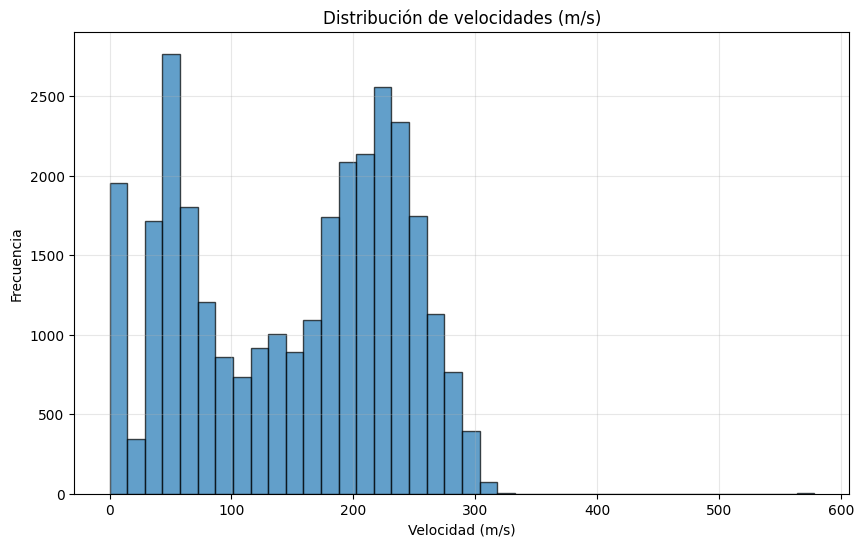

📈 Histograma de velocidades generado correctamente.


In [0]:
# --- Distribución de velocidades (velocity) ---
# Se genera un histograma para observar la distribución general de velocidades
# en el snapshot dinámico. Se filtran valores nulos y se limita el rango
# a velocidades positivas para evitar distorsiones.

# Conversión a pandas para visualización
df_velocity = df_states_gold_final.select("velocity").toPandas()["velocity"]

df_velocity = df_velocity.dropna()
df_velocity = df_velocity[df_velocity > 0]  # velocidad debe ser positiva

plt.hist(df_velocity, bins=40, edgecolor="black", alpha=0.7)

plt.title("Distribución de velocidades (m/s)")
plt.xlabel("Velocidad (m/s)")
plt.ylabel("Frecuencia")
plt.grid(True, alpha=0.3)

plt.show()

print("📈 Histograma de velocidades generado correctamente.")

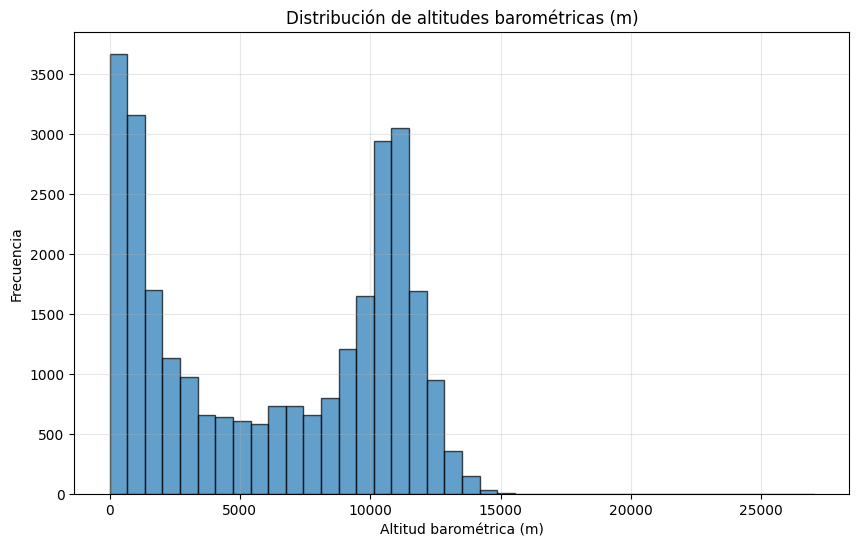

📊 Histograma de altitudes barométricas generado correctamente.


In [0]:
# --- Distribución de altitudes barométricas (baro_altitude) ---
# Se genera un histograma básico para explorar la distribución de la altitud barométrica.
# Se eliminan valores nulos y se filtran altitudes negativas para evitar distorsiones.

# Conversión a pandas para visualización
df_baro = df_states_gold_final.select("baro_altitude").toPandas()["baro_altitude"]

df_baro = df_baro.dropna()
df_baro = df_baro[df_baro >= 0]

plt.hist(df_baro, bins=40, edgecolor="black", alpha=0.7)

plt.title("Distribución de altitudes barométricas (m)")
plt.xlabel("Altitud barométrica (m)")
plt.ylabel("Frecuencia")
plt.grid(True, alpha=0.3)

plt.show()

print("📊 Histograma de altitudes barométricas generado correctamente.")

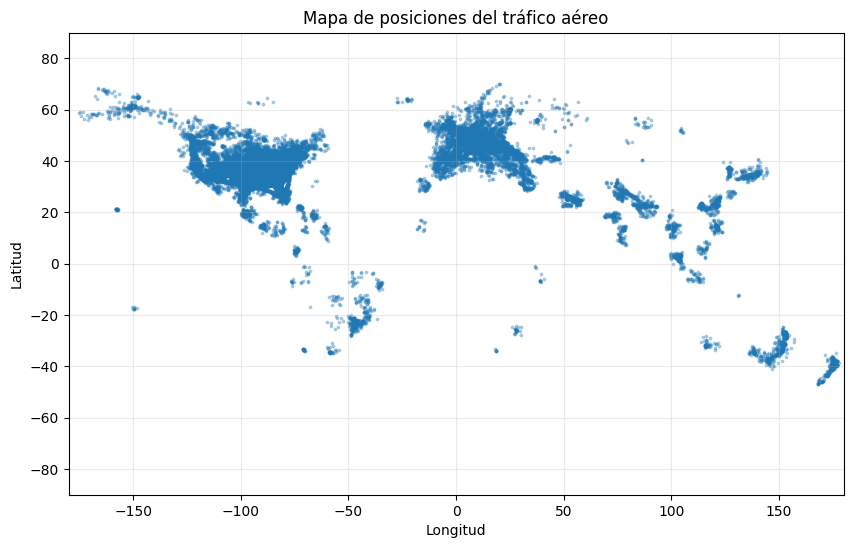

🗺️ Mapa scatter de posiciones generado.


In [0]:
# --- Scatter geográfico de posiciones ---
# Se grafican las coordenadas válidas del snapshot dinámico para visualizar
# la distribución global del tráfico aéreo. 
#
# Se ajustan el tamaño de los puntos y la transparencia para obtener una
# visualización más clara, especialmente cuando hay miles de aeronaves.
# También se fijan los límites geográficos del mapa (-180 a 180, -90 a 90)
# para mantener una representación consistente del espacio geográfico.

# Conversión a pandas para visualización
df_coords = df_states_gold_final \
    .select("latitude", "longitude") \
    .dropna() \
    .toPandas()

plt.scatter(
    df_coords["longitude"],
    df_coords["latitude"],
    s=3,           # puntos más pequeños → mayor claridad visual
    alpha=0.3      # mayor transparencia → evita saturación
)

plt.xlim(-180, 180)
plt.ylim(-90, 90)

plt.title("Mapa de posiciones del tráfico aéreo")
plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.grid(True, alpha=0.25)

plt.show()

print("🗺️ Mapa scatter de posiciones generado.")

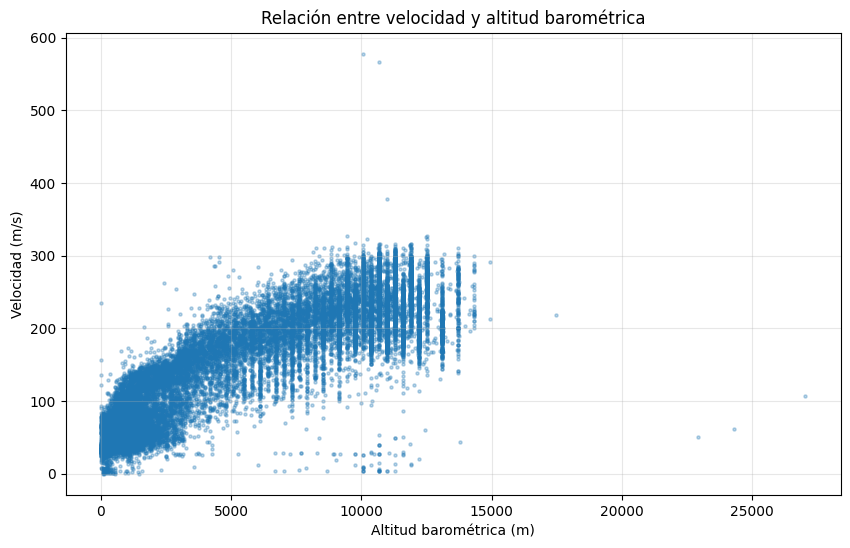

📉 Scatter velocidad vs. altitud barométrica generado.


In [0]:
# --- Relación entre velocidad y altitud barométrica ---
# Se utiliza un scatterplot para observar cómo varía la velocidad en función
# de la altitud barométrica. Se eliminan registros con valores nulos y se
# filtran valores negativos para aumentar la calidad de la visualización.

# Conversión a pandas para visualización
df_scatter_baro = (
    df_states_gold_final
    .select("velocity", "baro_altitude")
    .dropna()
    .toPandas()
)

df_scatter_baro = df_scatter_baro[
    (df_scatter_baro["velocity"] > 0) & 
    (df_scatter_baro["baro_altitude"] >= 0)
]

plt.scatter(
    df_scatter_baro["baro_altitude"],
    df_scatter_baro["velocity"],
    s=5,
    alpha=0.3
)

plt.title("Relación entre velocidad y altitud barométrica")
plt.xlabel("Altitud barométrica (m)")
plt.ylabel("Velocidad (m/s)")
plt.grid(True, alpha=0.3)

plt.show()

print("📉 Scatter velocidad vs. altitud barométrica generado.")

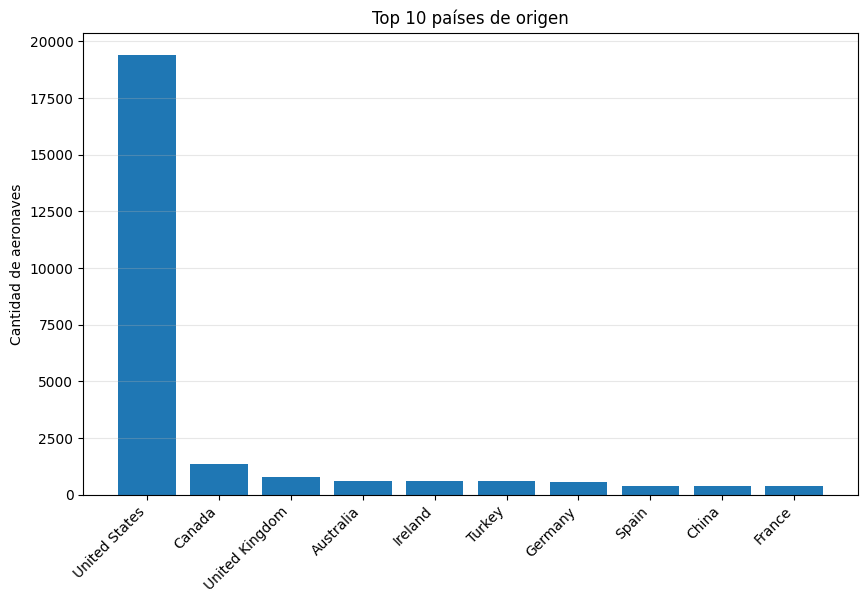

🌍 Gráfico de Top 10 países generado.


In [0]:
# --- Gráfico de barras: Top 10 países de origen ---
# Permite observar rápidamente qué países contribuyen más al snapshot.

# Conversión a pandas para visualización
top_paises = (
    df_states_gold_final
    .select("origin_country")
    .toPandas()["origin_country"]
    .value_counts()
    .head(10)
)

plt.bar(top_paises.index, top_paises.values)
plt.title("Top 10 países de origen")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Cantidad de aeronaves")
plt.grid(True, axis="y", alpha=0.3)

plt.show()

print("🌍 Gráfico de Top 10 países generado.")

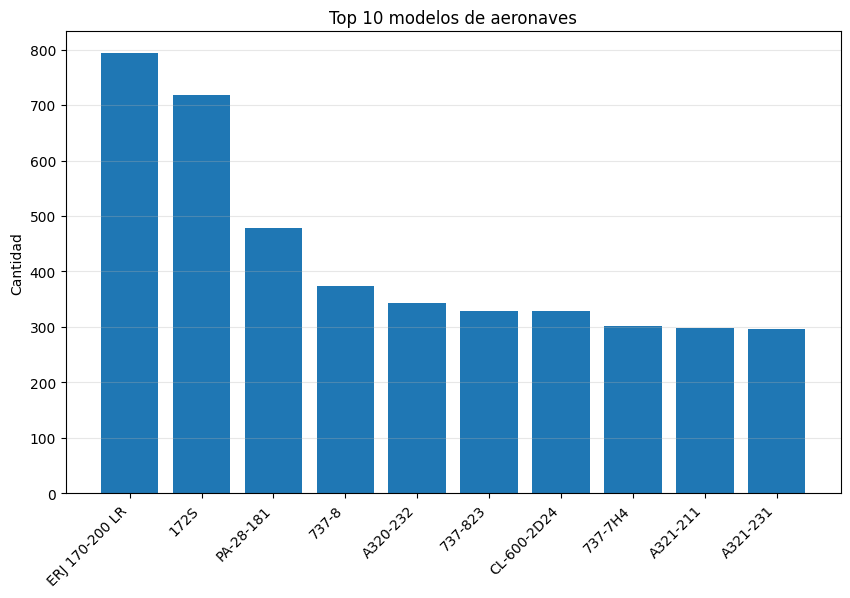

🛩️ Gráfico de modelos de aeronaves generado.


In [0]:
# --- Distribución de modelos de aeronaves ---
# Se grafican los 10 modelos más frecuentes detectados en el snapshot Gold.

# Conversión a pandas para visualización
top_modelos = (
    df_states_gold_final
    .select("model")
    .toPandas()["model"]
    .value_counts()
    .head(10)
)

plt.bar(top_modelos.index, top_modelos.values)
plt.title("Top 10 modelos de aeronaves")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Cantidad")
plt.grid(True, axis="y", alpha=0.3)

plt.show()

print("🛩️ Gráfico de modelos de aeronaves generado.")

### 4.6 Cierre del apartado Gold

En esta sección se consolidaron las métricas descriptivas, el enriquecimiento con metadatos de aeronaves y un conjunto de visualizaciones básicas que permiten validar el comportamiento general del tráfico aéreo capturado en el snapshot dinámico.

El propósito no es realizar un análisis aeronáutico exhaustivo, sino demostrar que los datos procesados en la capa Gold son coherentes, enriquecidos y listos para su utilización en distintos entornos analíticos.

Las tareas principales realizadas incluyen:

- lectura del dataset dinámico desde Silver
- validación y ajustes finales del esquema para análisis
- cálculo de métricas operativas
- integración con la tabla estática de aeronaves
- preparación del dataset final consolidado
- almacenamiento en la capa Gold (Parquet)
- exportación a CSV y Parquet
- generación de visualizaciones complementarias

Con esto, la capa Gold completa el flujo Bronze → Silver → Gold, entregando un dataset final curado, estructurado y enriquecido, apto para análisis exploratorio, dashboards o procesamiento adicional en pipelines posteriores.

## 5. Conclusiones del pipeline

Este proyecto implementa un pipeline de Ingeniería de Datos sobre información aeronáutica pública, siguiendo la arquitectura **Bronze → Silver → Gold** y aplicando procesos de limpieza, normalización, enriquecimiento y persistencia de datos en un entorno cloud con **Apache Spark sobre Azure Databricks**.

La versión cloud se ejecuta de forma **manual en un único notebook**, y persiste los datasets en **Azure Data Lake Storage Gen2 (ADLS)** mediante rutas `abfss://`, almacenando los datos en formato **Parquet**. Esto permite reproducir una arquitectura de Data Lake en la nube con separación por capas y almacenamiento durable.

En paralelo, el proyecto cuenta con una **versión local** (en el repositorio) implementada mayormente con **pandas** y persistencia en **Delta Lake**, además de una variante **orquestada con Prefect**, que permite:

- automatizar la ejecución del pipeline  
- gestionar dependencias entre tareas  
- centralizar logs y monitoreo  
- habilitar ingestas periódicas  

De esta manera, el proyecto establece una base técnica reproducible para el procesamiento de datos aeronáuticos y su posterior análisis.

---

## 🔄 Roadmap futuro

A partir de la implementación actual, los siguientes pasos de evolución incluyen:

### 1) Evolución a arquitectura Lakehouse
- incorporación de **Delta Lake** en la versión cloud para:
  - versionado de datos  
  - control de esquema  
  - operaciones de actualización (upserts)  

### 2) Orquestación en la nube
- migración de la orquestación (Prefect) a un entorno cloud  
- ejecución programada y monitoreo de runs  

### 3) Análisis histórico y dashboards
- acumulación temporal eficiente de snapshots  
- construcción de series de tiempo e indicadores  
- integración con herramientas de BI como Power BI  

---

## 🏁 Cierre

El proyecto muestra cómo transformar datos crudos provenientes de una fuente pública en un dataset estructurado y listo para análisis, utilizando procesamiento distribuido y prácticas habituales de Ingeniería de Datos en entornos de nube, manteniendo una evolución coherente desde prototipos locales hacia ejecución cloud.